<h1 style="text-align: center;">Fraud Detections & Data Quality Analysis Of GrabUnlimited Transactions In GrabFood</h1>
<h3 style="text-align: center;">Zian Carlos Wong & Valencia</h3>

---

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df_food_orders_raw = pd.read_csv("../data/raw/grab_food_orders.csv")
df_merchants_raw = pd.read_csv("../data/raw/grab_merchants.csv")
df_users_raw = pd.read_csv("../data/raw/grab_users.csv")

df_food_orders_cleaned = df_food_orders_raw.copy()
df_merchants_cleaned = df_merchants_raw.copy()
df_users_cleaned = df_users_raw.copy()

In [3]:
df_food_orders_cleaned.head()

,order_id,merchant_id,user_id,order_status,promo_discount,cancel_reason,order_time,driver_arrived_time,completed_time
0,GF-ORD-00000001,GF-06555,GB-019659,Completed,0,NaN,2023-12-21 09:43:00,2023-12-21 10:00:00,2023-12-21 10:16:00
1,GF-ORD-00000002,GF-07698,GB-019520,Cancel,0,Resto Tidak Ditemukan,2023-12-20 14:01:00,2023-12-20 14:13:00,NaN
2,GF-ORD-00000003,GF-02054,GB-030006,CANCELED,15000,Menu Habis,2024-02-18 12:56:00,2024-02-18 13:06:00,NaN
3,GF-ORD-00000004,GF-05867,GB-021929,Completed,30000,NaN,2023-12-21 16:12:00,2023-12-21 16:24:00,2023-12-21 16:58:00
4,GF-ORD-00000005,GF-06915,GB-008802,DONE,0,NaN,2024-02-03 09:13:00,2024-02-03 09:20:00,2024-02-03 09:36:00


In [4]:
df_merchants_cleaned.head()

,merchant_id,merchant_name,cuisine_type,city
0,GF-00001,Resto GrabMantap 0,Seafood,Depok
1,GF-00002,Resto GrabMantap 1,Fast Food,Surabaya
2,GF-00003,Resto GrabMantap 2,Martabak,Tangerang
3,GF-00004,Resto GrabMantap 3,Martabak,Jakarta
4,GF-00005,Resto GrabMantap 4,Snacks,Bekasi


In [5]:
df_users_cleaned.head()

,user_id,is_grab_unlimited,account_age_days
0,GB-000001,False,91
1,GB-000002,False,1048
2,GB-000003,True,985
3,GB-000004,True,1357
4,GB-000005,False,16


## **Section 1. Business Context**

**1.1 Context**

    Grab meluncurkan program subscription GrabUnlimited untuk meningkatkan retensi pelanggan dalam ekosistem Grab dengan membayar biaya layanan bulanan untuk mendapatkan voucher gratis ongkir dan diskon untuk setiap pemesanan GrabFood.

    Strategi ini sukses membuat jumlah frekuensi transaksi meningkat, tetapi terdapat aktifitas fraud dengan cara membuat resto fiktif dan memesan makanan fiktif ke resto tersebut. Oleh karena itu, Grab harus menanggung kerugian yang besar akibat mensubsidi diskon makanan dan biaya ongkir serta pembatalan pesanan mengakibatkan kerusakan metrik performa operasional.
    
    Tim Data Engineer dan Fraud Analyst mengalami kesulitan untuk mengidentifikasi aktifitas fraud akibat kualitas data yang buruk seperti alasan pembatalan yang seringkali tidak konsisten dan dibiarkan kosong serta terdapat bug sistem yang memungkinkan pesanan selesai tanpa menunggu driver tiba di titik penjemputan. Oleh karena itu, diperlukan analisis data untuk mengidentifikasi pola transaksi mencurigakan pada pemakaian GrabUnlimited.

**1.2 Problem Statements**

Masalah Utama: Kerugian finansial yang masif akibat eksploitasi subsidi GrabUnlimited oleh sindikat Resto Fiktif serta tingginya Cancellation Rate yang merugikan driver organik.

Masalah Turunan:
1.	Merchant mana saja yang memiliki rasio transaksi sukses sangat tinggi, tetapi pembelinya hanya berasal dari 2-3 akun user yang sama secara terus-menerus?
2.	Berapa estimasi uang subsidi promo (GrabUnlimited) yang terbuang sia-sia untuk transaksi yang terindikasi fiktif?
3.	Seberapa kotor dan tidak konsistennya penulisan status pesanan dan alasan pembatalan di dalam database?
4.	Berapa persentase pesanan batal yang tidak memiliki keterangan Cancel Reason (Missing Values), sehingga menyulitkan investigasi tim operasional?
5.	Berapa banyak pesanan berstatus 'Completed' di mana jam 'Pesanan Selesai' (Completed Time) terjadi sebelum jam 'Driver Tiba di Resto' (Driver Arrived Time)?
6.	Kategori makanan (Cuisine Type) apa yang paling sering digunakan sebagai kedok oleh Resto Fiktif untuk memanipulasi harga menu tinggi?


**1.3 Key Objective**

1. Mengidentifikasi merchant yang terindentifikasi sebagai resto fiktif
2. Mengestimasi kerugian finasial dari uang promo yang terbuang akibat transaksi fiktif
3. Mengidentifikasi inkonsistensi dan melakukan standarisasi penulisan database seperti status pesanan serta mengidentifikasi dan melakukan penanganan terhadap missing values
4. Mendeteksi anomali / nilai ekstrem pada data

## **Section 2. Data Understanding**

**2.1 General Information**

In [6]:
df_food_orders_cleaned.info()

<class 'pandas.DataFrame'>
RangeIndex: 300000 entries, 0 to 299999
Data columns (total 9 columns):
 #   Column               Non-Null Count   Dtype
---  ------               --------------   -----
 0   order_id             300000 non-null  str  
 1   merchant_id          300000 non-null  str  
 2   user_id              300000 non-null  str  
 3   order_status         300000 non-null  str  
 4   promo_discount       300000 non-null  int64
 5   cancel_reason        35780 non-null   str  
 6   order_time           300000 non-null  str  
 7   driver_arrived_time  270320 non-null  str  
 8   completed_time       240093 non-null  str  
dtypes: int64(1), str(8)
memory usage: 47.3 MB


In [7]:
df_merchants_cleaned.info()

<class 'pandas.DataFrame'>
RangeIndex: 8000 entries, 0 to 7999
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   merchant_id    8000 non-null   str  
 1   merchant_name  8000 non-null   str  
 2   cuisine_type   8000 non-null   str  
 3   city           8000 non-null   str  
dtypes: str(4)
memory usage: 590.8 KB


In [8]:
df_users_cleaned.info()

<class 'pandas.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 3 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   user_id            40000 non-null  str  
 1   is_grab_unlimited  40000 non-null  bool 
 2   account_age_days   40000 non-null  int64
dtypes: bool(1), int64(1), str(1)
memory usage: 1015.8 KB


In [9]:
print("food orders table shape:", df_food_orders_cleaned.shape)
print("merchant table shape:", df_merchants_cleaned.shape)
print("users table shape:", df_users_cleaned.shape)

food orders table shape: (300000, 9)
merchant table shape: (8000, 4)
users table shape: (40000, 3)


**2.2 Feature Information**

In [10]:
print("Food orders Table list of colums:", df_food_orders_cleaned.columns.tolist())
print("Merchants Table list of colums:", df_merchants_cleaned.columns.tolist())
print("Users Table list of colums:", df_users_cleaned.columns.tolist())


Food orders Table list of colums: ['order_id', 'merchant_id', 'user_id', 'order_status', 'promo_discount', 'cancel_reason', 'order_time', 'driver_arrived_time', 'completed_time']
Merchants Table list of colums: ['merchant_id', 'merchant_name', 'cuisine_type', 'city']
Users Table list of colums: ['user_id', 'is_grab_unlimited', 'account_age_days']


In [11]:
print("Food Orders Table Each Column Null Values Sum")
display(df_food_orders_cleaned.isnull().sum())


Food Orders Table Each Column Null Values Sum


order_id                    0
merchant_id                 0
user_id                     0
order_status                0
promo_discount              0
cancel_reason          264220
order_time                  0
driver_arrived_time     29680
completed_time          59907
dtype: int64

In [12]:
print("Merchants Table Each Column Null Values Sum")
display(df_merchants_cleaned.isnull().sum())


Merchants Table Each Column Null Values Sum


merchant_id      0
merchant_name    0
cuisine_type     0
city             0
dtype: int64

In [13]:
print("Users Table Each Column Null Values Sum")
display(df_users_cleaned.isnull().sum())


Users Table Each Column Null Values Sum


user_id              0
is_grab_unlimited    0
account_age_days     0
dtype: int64

**2.3 Statistics Summary**

In [14]:
df_food_orders_cleaned.describe()

,promo_discount
count,3.000000e+05
mean,6.035158e+04
std,7.018429e+05
min,-5.000000e+03
25%,0.000000e+00
50%,1.000000e+04
75%,2.000000e+04
max,9.999999e+06


In [15]:
df_merchants_cleaned.describe()

,merchant_id,merchant_name,cuisine_type,city
count,8000,8000,8000,8000
unique,8000,8000,6,10
top,GF-00001,Resto GrabMantap 0,Ayam Geprek,Bekasi
freq,1,1,1388,861


In [16]:
df_users_cleaned.describe()

,account_age_days
count,40000.000000
mean,750.897150
std,431.156788
min,1.000000
25%,378.000000
50%,753.000000
75%,1122.000000
max,1499.000000


## **Section 3. Data Cleaning**

**3.1 Duplicated Values**

In [17]:
# (3.1.1.1) Check duplicate rows in dataset
# Step: Identify fully duplicated records across all columns

print("Food Orders Duplicated Rows:", df_food_orders_cleaned.duplicated().sum())
print("Merchants Duplicated Rows:",df_merchants_cleaned.duplicated().sum())
print("Users Duplicated Rows:",df_users_cleaned.duplicated().sum())

Food Orders Duplicated Rows: 0
Merchants Duplicated Rows: 0
Users Duplicated Rows: 0


In [18]:
# (3.1.2.1) Check duplicate rows in dataset primary key & must unique columns
# Step: Identify fully duplicated records across all columns

print("Food Orders Primary Key Is Unique:", df_food_orders_cleaned["order_id"].is_unique)
print("Merchants Id Primary Key Is Unique:",df_merchants_cleaned["merchant_id"].is_unique)
print("Merchants Name Is Unique:",df_merchants_cleaned["merchant_name"].is_unique)
print("Users Primary Key Is Unique:",df_users_cleaned["user_id"].is_unique)

Food Orders Primary Key Is Unique: True
Merchants Id Primary Key Is Unique: True
Merchants Name Is Unique: True
Users Primary Key Is Unique: True


**3.2 Identify Spelling Errors**

In [19]:
# (3.2.1.1) Identify spelling inconsistencies in the 'order_status' feature
# Step 1:
# Check the unique values to identify inconsistent spellings,
# capitalization, or synonyms.

print("Unique values in 'order_status':")
print(df_food_orders_cleaned["order_status"].unique())

Unique values in 'order_status':
<ArrowStringArray>
['Completed', 'Cancel', 'CANCELED', 'DONE', 'Selesai', 'batal', 'Failed']
Length: 7, dtype: str


In [20]:
# (3.2.1.2) Standardize categorical values in 'order_status'
# Step 2: Normalize inconsistent labels due to spelling, casing, or language differences
# - Merge different representations of Completed, Cancelled, and Failed into a single standard format
# - This ensures consistent grouping for analysis and avoids duplicate categories

df_food_orders_cleaned["order_status"] = df_food_orders_cleaned["order_status"].replace({
    "Completed": "Completed",
    "DONE": "Completed",
    "Selesai": "Completed",

    "Cancel": "Cancelled",
    "CANCELED": "Cancelled",
    "batal": "Cancelled",

    "Failed": "Failed"
})

**3.3 Missing Values**

In [21]:
# (3.3.3.1) Analyze relationship between 'order_status' and 'cancel_reason'
# Step: Create a cross-tabulation to understand how cancellation reasons
#       are distributed across different order statuses
# - dropna=False ensures missing values are included in the analysis
# - Useful for data quality checks and identifying inconsistent labeling
# - Helps validate whether cancel_reason aligns with order_status logic

pd.crosstab(
    df_food_orders_cleaned["order_status"],
    df_food_orders_cleaned["cancel_reason"],
    dropna=False
)

cancel_reason,Driver Terlalu Jauh,Menu Habis,Resto Tidak Ditemukan,Resto Tutup,NaN
order_status,,,,,
Cancelled,4559,4509,8792,8946,18053
Completed,0,0,0,0,240093
Failed,1477,1507,3016,2974,6074


In [22]:
# (3.3.2.2) Handle missing values in 'cancel_reason'
# Step: Impute missing cancellation reasons based on order_status
# - Completed orders → "Not Applicable" (no cancellation occurred)
# - Keeps Cancelled and Failed reasons intact for root-cause analysis
# - Avoids misinterpretation of NaN values in reporting or modeling

df_food_orders_cleaned.loc[
    df_food_orders_cleaned["order_status"] == "Completed",
    "cancel_reason"
] = "Not Applicable"

In [23]:
# (3.3.2.3) Standardize missing values in 'cancel_reason'
# Step: Convert all invalid missing representations into proper NaN
# - Handles string "nan" which comes from data ingestion issues
# - Ensures consistent missing value format for analysis

df_food_orders_cleaned["cancel_reason"] = (
    df_food_orders_cleaned["cancel_reason"]
    .replace("nan", np.nan)
)

In [24]:
# (3.3.2.4) Handle missing cancel_reason for non-completed outcomes
# Step: Assign explicit label for orders with missing cancellation reason
# - Applies only when cancel_reason is truly missing (NaN)
# - Improves interpretability for reporting and analysis

df_food_orders_cleaned.loc[
    df_food_orders_cleaned["cancel_reason"].isna(),
    "cancel_reason"
] = "No Reason Provided"

In [25]:
# (3.3.3.5) Clean cross-tab of order_status vs cancel_reason
# Step: Replace missing reasons with "Unknown" and compute distribution
# - Improves clarity in dashboards and stakeholder reporting

pd.crosstab(
    df_food_orders_cleaned["order_status"],
    df_food_orders_cleaned["cancel_reason"].fillna("Unknown"),
    margins=True
)

cancel_reason,Driver Terlalu Jauh,Menu Habis,No Reason Provided,Not Applicable,Resto Tidak Ditemukan,Resto Tutup,All
order_status,,,,,,,
Cancelled,4559,4509,18053,0,8792,8946,44859
Completed,0,0,0,240093,0,0,240093
Failed,1477,1507,6074,0,3016,2974,15048
All,6036,6016,24127,240093,11808,11920,300000


**3.4 Identify Anomaly Values**

In [26]:
# (3.4.1.1) Validate Completed order completeness
# Step: Check Completed orders with missing lifecycle timestamps
# - Either driver_arrived_time or completed_time is missing
# - Indicates potential data quality or logging issues

count_missing = df_food_orders_cleaned[
    (df_food_orders_cleaned["order_status"] == "Completed") &
    (
        df_food_orders_cleaned["driver_arrived_time"].isna() |
        df_food_orders_cleaned["completed_time"].isna()
    )
].shape[0]

print(f"Completed orders with missing timestamps: {count_missing}")

Completed orders with missing timestamps: 0


In [27]:
# (3.4.2.1) Validate promo_discount values
# Step: Identify invalid negative discount values
# - promo_discount should not be negative in normal business logic
# - Negative values may indicate data entry or system issues

df_food_orders_cleaned["promo_discount"].value_counts()

promo_discount
 0          115312
 10000       57388
 20000       43028
 15000       42892
 30000       38489
 9999999      1488
-5000         1403
Name: count, dtype: int64

In [28]:
# (3.4.2.2) Identify invalid promo_discount sentinel values
# - Certain extreme values (9999999, -5000) are system placeholders / data errors
# - These are not real discounts and should be treated as invalid

df_food_orders_cleaned["promo_discount_sentinel"] = (
    df_food_orders_cleaned["promo_discount"].isin([-5000, 9999999])
)

In [29]:
# (3.4.2.3) Promo discount distribution AFTER cleaning
# Sentinel values removed to avoid bias in statistics
# Sentinel values replaced by 0 to represent "no discount was given"

df_food_orders_cleaned["promo_discount"] = df_food_orders_cleaned["promo_discount"].replace(
    [-5000, 9999999],
    0
)

In [30]:
# (3.4.2.4) Validate promo_discount values (AFTER cleaning)
# Step: Re-check distribution after removing invalid sentinel values
# - Ensures analysis is not biased by system error codes

print("AFTER CLEANING - promo_discount_clean value counts")
print(df_food_orders_cleaned["promo_discount"].value_counts(dropna=False))

AFTER CLEANING - promo_discount_clean value counts
promo_discount
0        118203
10000     57388
20000     43028
15000     42892
30000     38489
Name: count, dtype: int64


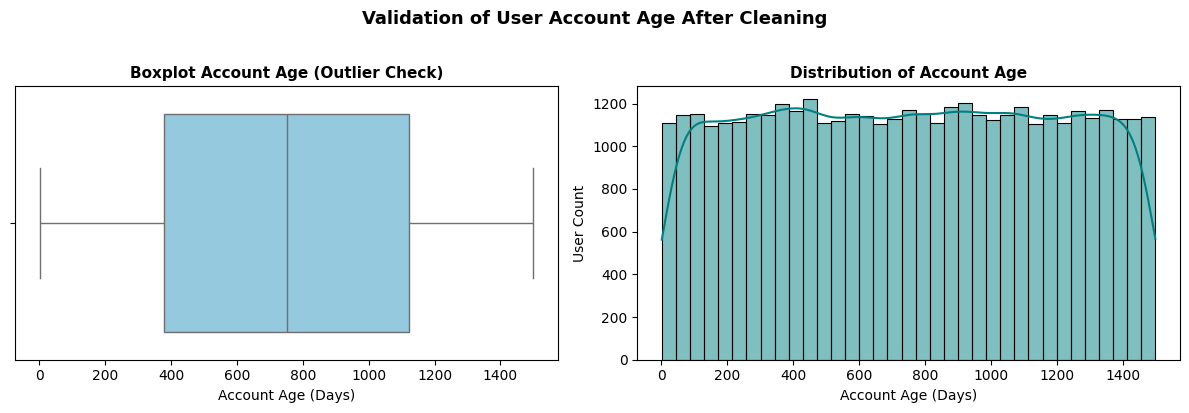

In [31]:
# (3.4.3.1) Validate User Column account_age_days
# Step: Re-check distribution after removing invalid sentinel values
# - Ensures No Outlier values
# - Result is uniformly distributed

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.boxplot(x=df_users_cleaned["account_age_days"], ax=axes[0], color="skyblue")
axes[0].set_title("Boxplot Account Age (Outlier Check)", fontsize=11, fontweight="bold")
axes[0].set_xlabel("Account Age (Days)")

sns.histplot(df_users_cleaned["account_age_days"], ax=axes[1], kde=True, color="teal")
axes[1].set_title("Distribution of Account Age", fontsize=11, fontweight="bold")
axes[1].set_xlabel("Account Age (Days)")
axes[1].set_ylabel("User Count")

plt.suptitle("Validation of User Account Age After Cleaning", fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()


**3.5 Standardize columns to intended datatypes**

In [32]:
# (3.5.1) Standardize column data types to datetime format
# Step: Convert object/string columns into proper datetime format

df_food_orders_cleaned["order_time"] = pd.to_datetime(
    df_food_orders_cleaned["order_time"],    
    errors="coerce")
df_food_orders_cleaned["driver_arrived_time"] = pd.to_datetime(
    df_food_orders_cleaned["driver_arrived_time"],
    errors="coerce"
)
df_food_orders_cleaned["completed_time"] = pd.to_datetime(
    df_food_orders_cleaned["completed_time"],
    errors="coerce"
)

In [33]:
# (3.5.2) Feature extraction from order_time
# Step: Extract useful time-based features for analysis
# - Helps understand temporal patterns (year, month, day, day_name)
# - Useful for trend analysis and business reporting

df_food_orders_cleaned["order_year"] = df_food_orders_cleaned["order_time"].dt.year.astype("Int64")
df_food_orders_cleaned["order_month"] = df_food_orders_cleaned["order_time"].dt.month.astype("Int64")
df_food_orders_cleaned["order_day"] = df_food_orders_cleaned["order_time"].dt.day.astype("Int64")
df_food_orders_cleaned["order_day_name"] = df_food_orders_cleaned["order_time"].dt.day_name()

In [34]:
# (3.5.3) Feature extraction from driver_arrived_time
# Step: Extract useful time-based features for analysis
# - Helps understand temporal patterns (year, month, day, day_name)
# - Useful for trend analysis and business reporting

df_food_orders_cleaned["driver_arrived_year"] = df_food_orders_cleaned["driver_arrived_time"].dt.year.astype("Int64")
df_food_orders_cleaned["driver_arrived_month"] = df_food_orders_cleaned["driver_arrived_time"].dt.month.astype("Int64")
df_food_orders_cleaned["driver_arrived_day"] = df_food_orders_cleaned["driver_arrived_time"].dt.day.astype("Int64")
df_food_orders_cleaned["driver_arrived_day_name"] = df_food_orders_cleaned["driver_arrived_time"].dt.day_name()

In [35]:
# (3.5.4) Feature extraction from completed_time
# Step: Extract useful time-based features for analysis
# - Helps understand temporal patterns (year, month, day, day_name)
# - Useful for trend analysis and business reporting

df_food_orders_cleaned["completed_year"] = df_food_orders_cleaned["completed_time"].dt.year.astype("Int64")
df_food_orders_cleaned["completed_month"] = df_food_orders_cleaned["completed_time"].dt.month.astype("Int64")
df_food_orders_cleaned["completed_day"] = df_food_orders_cleaned["completed_time"].dt.day.astype("Int64")
df_food_orders_cleaned["completed_day_name"] = df_food_orders_cleaned["completed_time"].dt.day_name()

**3.6 Export The Final Cleaned Results**

In [36]:
# (3.6.1) Export All Results
# Step: Export The Final Clean Results

df_food_orders_cleaned.to_csv("../data/cleaned/grab_food_orders_cleaned.csv", index=False)
df_merchants_cleaned.to_csv("../data/cleaned/grab_merchants_cleaned.csv", index=False)
df_users_cleaned.to_csv("../data/cleaned/users_cleaned.csv", index=False)

## **Section 4. Analytics**

In [37]:
# 4.0.1 Read The New Cleaned Datasets

time_extracted_cols = [
    "order_year", "order_month", "order_day",
    "driver_arrived_year", "driver_arrived_month", "driver_arrived_day",
    "completed_year", "completed_month", "completed_day"
]

df_food_orders_cleaned = pd.read_csv("../data/cleaned/grab_food_orders_cleaned.csv", parse_dates=["order_time", "driver_arrived_time", "completed_time"], dtype={col: "Int64" for col in time_extracted_cols})

In [38]:
df_food_orders_cleaned.head()

,order_id,merchant_id,user_id,order_status,promo_discount,cancel_reason,order_time,driver_arrived_time,completed_time,promo_discount_sentinel,...,order_day,order_day_name,driver_arrived_year,driver_arrived_month,driver_arrived_day,driver_arrived_day_name,completed_year,completed_month,completed_day,completed_day_name
0,GF-ORD-00000001,GF-06555,GB-019659,Completed,0,Not Applicable,2023-12-21 09:43:00,2023-12-21 10:00:00,2023-12-21 10:16:00,False,...,21,Thursday,2023,12,21,Thursday,2023,12,21,Thursday
1,GF-ORD-00000002,GF-07698,GB-019520,Cancelled,0,Resto Tidak Ditemukan,2023-12-20 14:01:00,2023-12-20 14:13:00,NaT,False,...,20,Wednesday,2023,12,20,Wednesday,<NA>,<NA>,<NA>,NaN
2,GF-ORD-00000003,GF-02054,GB-030006,Cancelled,15000,Menu Habis,2024-02-18 12:56:00,2024-02-18 13:06:00,NaT,False,...,18,Sunday,2024,2,18,Sunday,<NA>,<NA>,<NA>,NaN
3,GF-ORD-00000004,GF-05867,GB-021929,Completed,30000,Not Applicable,2023-12-21 16:12:00,2023-12-21 16:24:00,2023-12-21 16:58:00,False,...,21,Thursday,2023,12,21,Thursday,2023,12,21,Thursday
4,GF-ORD-00000005,GF-06915,GB-008802,Completed,0,Not Applicable,2024-02-03 09:13:00,2024-02-03 09:20:00,2024-02-03 09:36:00,False,...,3,Saturday,2024,2,3,Saturday,2024,2,3,Saturday


### **4.1 Question 1 Masalah Utama**

Merchant mana saja yang memiliki rasio transaksi sukses sangat tinggi, tetapi pembelinya hanya berasal dari 2-3 akun user yang sama secara terus-menerus?

---

#### **Kesimpulan & Temuan Data**

* **Tidak Ada Toko yang Mencurigakan:** Hasil pemeriksaan data menunjukkan tidak ada toko yang memiliki pesanan sukses sangat banyak tetapi pembelinya cuma berputar di 2-3 orang yang sama secara terus-menerus.
* **Pola Pembelian Sangat Wajar:** Perbandingan antara jumlah pesanan dan jumlah pembeli di setiap toko masih sangat normal. Angka tertinggi dalam data ini hanya berada di rasio **1,16** (artinya: ada toko yang mendapat 7 pesanan, dan pesanan tersebut dibeli oleh 6 orang yang berbeda).
* **Kesimpulan:** Semua transaksi sukses berjalan dengan normal, pembelinya menyebar dengan baik, dan tidak ada tanda-tanda kecurangan memakai akun palsu yang membeli di toko yang sama secara berulang-ulang.

In [39]:
# (4.1.1) Calculate the order_to_user_ratio Grouped by Merchant
# Step: Filter completed orders for GrabUnlimited users and calculate purchase frequency
# - Isolates successful transactions to measure valid order volume
# - Filters the dataset to include only GrabUnlimited subscribers
# - Groups data by merchant to find total orders, unique users, and their ratio
# - Sorts the results to find merchants with the highest repeat purchase behavior

# 1. Get all food_orders with order_status "Completed"
df_completed = df_food_orders_cleaned[df_food_orders_cleaned['order_status'] == 'Completed']

# 2. Merge food_orders with users table to get the is_grab_unlimited column
df_completed_unlimited = df_completed.merge(df_users_cleaned[['user_id', 'is_grab_unlimited']], on='user_id', how='inner')

# 3. Get all merged results where is_grab_unlimited is True
df_unlimited_only = df_completed_unlimited[df_completed_unlimited['is_grab_unlimited'] == True]

# 4. Group by merchant_id and calculate total orders and unique users
merchant_grouped = df_completed.groupby('merchant_id').agg(
    total_completed_orders=('order_id', 'count'),
    unique_users=('user_id', 'nunique'),
).reset_index()


# 5. Calculate the order-to-user ratio (Total Orders / Unique Users)
merchant_grouped['order_to_user_ratio'] = merchant_grouped['total_completed_orders'] / merchant_grouped['unique_users']

# 6. Sort the merchants by order_to_user_ratio in descending order
merchant_grouped = merchant_grouped.sort_values("order_to_user_ratio", ascending=False)

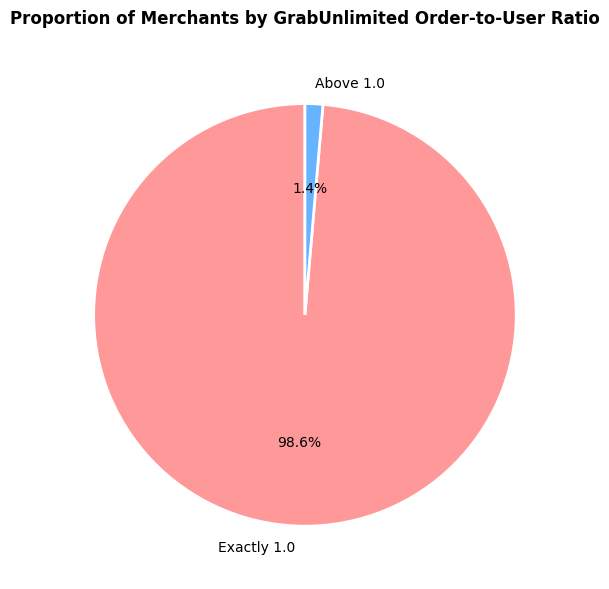

In [40]:
# (4.1.2) Visualize the Order-to-User Ratio Distribution
# Step: Categorize merchants using np.where and plot the clean proportion chart
import numpy as np

# 1. Categorize ratios and count total merchants per category in one step
merchant_grouped['kategori_ratio'] = np.where(merchant_grouped['order_to_user_ratio'] == 1.0, 'Exactly 1.0', 'Above 1.0')
donut_data = merchant_grouped['kategori_ratio'].value_counts()

# 2. Plot the pie chart with clean formatting
plt.figure(figsize=(6, 6))
plt.pie(
    donut_data, 
    labels=donut_data.index, 
    autopct='%1.1f%%', 
    startangle=90, 
    colors=['#ff9999', '#66b3ff'], 
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)

# 3. Add title, format layout, and save the final chart image
plt.title('Proportion of Merchants by GrabUnlimited Order-to-User Ratio', fontsize=12, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

In [41]:
# 4.1.3 Get the top 5 merchant with highest order to user ratio
merchant_grouped.head(10)

,merchant_id,total_completed_orders,unique_users,order_to_user_ratio,kategori_ratio
3861,GF-03862,19,18,1.055556,Above 1.0
4961,GF-04962,21,20,1.050000,Above 1.0
5885,GF-05886,22,21,1.047619,Above 1.0
1613,GF-01614,23,22,1.045455,Above 1.0
4779,GF-04780,23,22,1.045455,Above 1.0
1035,GF-01036,24,23,1.043478,Above 1.0
4323,GF-04324,25,24,1.041667,Above 1.0
1616,GF-01617,25,24,1.041667,Above 1.0
2673,GF-02674,25,24,1.041667,Above 1.0
7268,GF-07269,25,24,1.041667,Above 1.0


### **4.2 Question 2 Masalah Utama**

Berapa estimasi uang subsidi promo (GrabUnlimited) yang terbuang sia-sia untuk transaksi yang terindikasi fiktif?

---

#### **Key Insights & Metrics**

* **Number of Suspected Fake Merchants Identified:** 36 Merchants
* **Total estimated GrabUnlimited promo subsidy wasted on fake transactions:**
Rp 6,610,000.00



In [42]:
# (4.2.1) Find GrabUnlimited Merchants with the Highest Percentage of Cancelled Transactions
# Step: Filter for GrabUnlimited orders, create a status table per merchant, and calculate failure rates
# - Merges food orders with the users table to isolate GrabUnlimited subscribers
# - Groups transaction statuses specifically for GrabUnlimited orders by merchant_id
# - Calculates the combined failure rate (Cancelled + Failed) against GrabUnlimited Total Orders
# - Sorts the results to pinpoint high-risk merchants manipulating promo subsidies

# 1. Merge food_orders with users table to identify GrabUnlimited users
df_orders_user = df_food_orders_cleaned.merge(df_users_cleaned[['user_id', 'is_grab_unlimited']], on='user_id', how='inner')

# 2. Filter the dataset to keep ONLY GrabUnlimited user transactions
df_unlimited_orders = df_orders_user[df_orders_user['is_grab_unlimited'] == True]

# 3. Create a crosstab of order status per merchant_id based ONLY on GrabUnlimited orders
merchant_status_xtab = pd.crosstab(
    index=df_unlimited_orders['merchant_id'],
    columns=df_unlimited_orders['order_status'],
    margins=True,
    margins_name='Total_Orders'
)

# 4. Remove the summary 'Total_Orders' row from the index so it does not mess up the sorting
merchant_status_xtab = merchant_status_xtab.drop(index='Total_Orders', errors='ignore')

# 5. Calculate the pct_fail_to_total metric specifically for GrabUnlimited orders
cancelled_count = merchant_status_xtab['Cancelled'] if 'Cancelled' in merchant_status_xtab.columns else pd.Series(0, index=merchant_status_xtab.index)
failed_count = merchant_status_xtab['Failed'] if 'Failed' in merchant_status_xtab.columns else pd.Series(0, index=merchant_status_xtab.index)

merchant_status_xtab['pct_fail_to_total'] = (
    (cancelled_count + failed_count) / merchant_status_xtab['Total_Orders']
) * 100

# 6. Filter out low-volume merchants to prevent bias from inactive restaurants
min_order_threshold = 15
merchant_status_filtered = merchant_status_xtab[merchant_status_xtab['Total_Orders'] > min_order_threshold]

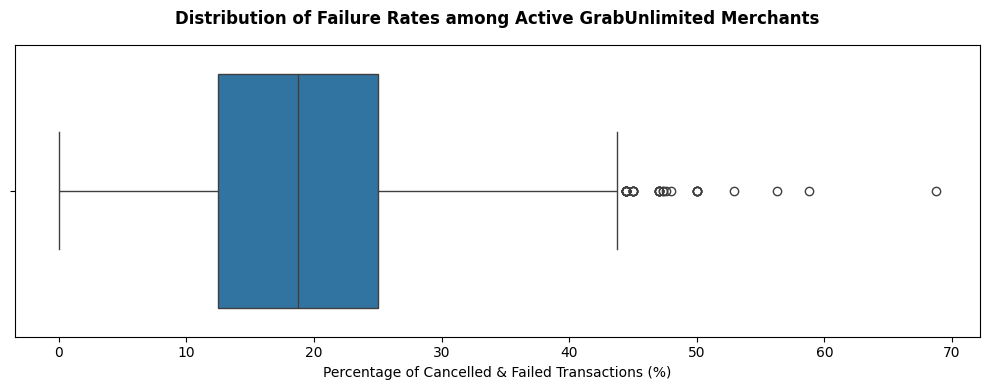

In [43]:
# (4.2.2) Visualize the Failure Rate Distribution to Detect Outliers

# 1. Set the figure size for the visualization
plt.figure(figsize=(10, 4))

# 2. Plot the failure rate distribution using a boxplot
sns.boxplot(x=merchant_status_filtered["pct_fail_to_total"])

# 3. Add titles and axis labels to describe the visualization
plt.title("Distribution of Failure Rates among Active GrabUnlimited Merchants", fontsize=12, fontweight='bold', pad=15)
plt.xlabel("Percentage of Cancelled & Failed Transactions (%)")

# 4. Format the layout and display the plot
plt.tight_layout()
plt.show()

In [44]:
# (4.2.3) Calculate Total Wasted Promo Subsidy from Suspected Fake Merchants
# Step: Compute the IQR threshold, extract high-risk merchants, and sum up wasted subsidies
# - Calculates the mathematical upper bound threshold using the Interquartile Range (IQR)
# - Filters for merchants exceeding this threshold to isolate highly suspicious dummy kitchens
# - Maps high-risk merchants back to orders to calculate total wasted GrabUnlimited promo discounts

# 1. Calculate the statistical upper bound threshold using the IQR method
Q1 = merchant_status_filtered['pct_fail_to_total'].quantile(0.25)
Q3 = merchant_status_filtered['pct_fail_to_total'].quantile(0.75)
IQR = Q3 - Q1
upper_bound_outlier = Q3 + (1.5 * IQR)

# 2. Extract and count high-risk suspected fake merchants exceeding the threshold
high_risk_merchants = merchant_status_filtered[
    merchant_status_filtered['pct_fail_to_total'] > upper_bound_outlier
].sort_values(by='pct_fail_to_total', ascending=False)


# 3. Filter GrabUnlimited orders for transactions belonging to high-risk merchants
df_fraud_orders = df_unlimited_orders[df_unlimited_orders["merchant_id"].isin(high_risk_merchants.index)]

# 4. Group by merchant to calculate individual wasted promo amounts
wasted_promo_per_merchant = df_fraud_orders.groupby("merchant_id")["promo_discount"].sum().sort_values(ascending=False)

display(len(wasted_promo_per_merchant))

# 5. Calculate and print the grand total of wasted subsidies for the main problem statement
total_wasted_subsidy = wasted_promo_per_merchant.sum()


# 6. Display The Results
BOLD_RED = "\033[1;31m"
RESET = "\033[0m"
print(f"{BOLD_RED}MAIN PROBLEM ANSWER:{RESET}")
print(f"Number of Suspected Fake Merchants Identified: {len(wasted_promo_per_merchant)}\n" + "="*80 + f"\n\033[1;31mMAIN PROBLEM ANSWER:\033[0m\nTotal estimated GrabUnlimited promo subsidy wasted on fake transactions:\n\033[1;31mRp {total_wasted_subsidy:,.2f}\033[0m\n" + "="*80)

36

MAIN PROBLEM ANSWER:
Number of Suspected Fake Merchants Identified: 36
MAIN PROBLEM ANSWER:
Total estimated GrabUnlimited promo subsidy wasted on fake transactions:
Rp 6,610,000.00


### **4.3 Question 3 Masalah Utama**

Seberapa kotor dan tidak konsistennya penulisan status pesanan dan alasan pembatalan di dalam database?

---

### **1. Kolom `order_status` (Masalah Inkonsistensi)**

* **Duplikasi Makna:** Terdapat 7 nilai variasi teks berbeda di dalam database yang secara semantik sebenarnya hanya mewakili 3 status dasar utama (*Completed*, *Cancelled*, dan *Failed*).
* *Contoh temuan:* Pencampuran bahasa (`Completed`, `DONE`, `Selesai`) serta ketidakseragaman kapitalisasi dan istilah untuk pembatalan (`Cancel`, `CANCELED`, `batal`).



---

### **2. Kolom `cancel_reason` (Masalah Ambiguitas / Missing Values)**

* **String Kosong Palsu:** Terdapat teks `"nan"` yang tertulis dalam bentuk *string* literal, bukan sebagai nilai kosong (*true missing value*) objek `NaN` bawaan Python.
* **Bias Status Completed:** Banyak baris data bernilai `NaN` (kosong) murni karena pesanan tersebut berstatus sukses (`Completed`). Kondisi ini menimbulkan ambiguitas jika tidak dipisahkan dengan pesanan yang gagal tanpa alasan, sehingga idealnya diubah menjadi kategori `"No Reason Provided"`.

### **4.4 Question 4 Masalah Utama**

Berapa persentase pesanan batal yang tidak memiliki keterangan Cancel Reason (Missing Values), sehingga menyulitkan investigasi tim operasional?

---

#### **Hasil Analisis Data**

* **Persentase Pesanan Batal Tanpa Alasan (No Reason Provided):** **40.24%**

---

#### **Kesimpulan & Dampak Operasional**

* **Hampir Setengah Data Hilang:** Sebanyak **40.24%** dari total seluruh pesanan yang batal tidak memiliki alasan pembatalan yang jelas di dalam database.
* **Menyulitkan Investigasi:** Angka yang cukup besar ini menjadi kendala utama bagi tim operasional. Ketiadaan data ini membuat tim kesulitan membedakan mana pembatalan yang murni karena masalah teknis (seperti resto tutup atau menu habis) dan mana pembatalan yang sengaja dimanipulasi untuk tujuan kecurangan (*fraud*).

In [45]:
# (4.4.1) Calculate Percentage of Cancelled Orders with Missing Reasons
# Step: Filter for cancelled orders, calculate relative frequencies, and extract the target metric
# - Isolates 'cancel_reason' data specifically for orders with a 'Cancelled' status
# - Computes the percentage distribution of all recorded cancellation reasons
# - Safely extracts the specific percentage for orders lacking a provided reason

# 1. Calculate the percentage distribution of all cancellation reasons for cancelled orders
cancel_reason_pct = df_food_orders_cleaned["cancel_reason"][
    df_food_orders_cleaned["order_status"] == "Cancelled"
].value_counts(normalize=True)

# 2. Extract the specific percentage for 'No Reason Provided' and convert to standard percentage format
no_reason_percentage = cancel_reason_pct.get("No Reason Provided", 0) * 100

# 3. Print the final calculated metric
print(f"Persentase Pesanan Batal Tanpa Alasan (No Reason Provided): {no_reason_percentage:.2f}%")

Persentase Pesanan Batal Tanpa Alasan (No Reason Provided): 40.24%


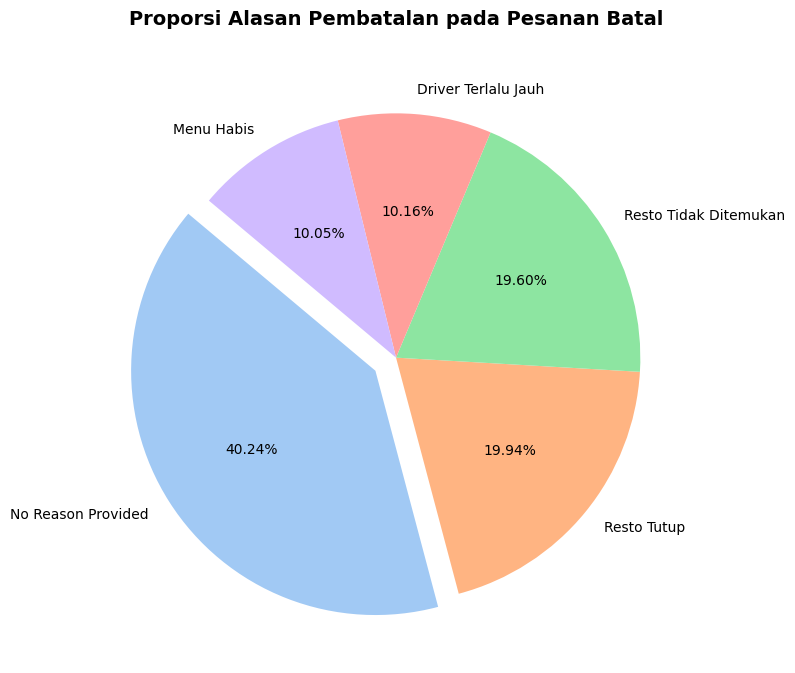

In [46]:
# (4.4.2) Visualize Cancel Reason Distribution Using a Pie Chart
# Step: Filter data, calculate counts, and plot a pie chart to show the missing reason share

# 1. Ambil data alasan pembatalan khusus untuk pesanan yang berstatus 'Cancelled'
cancelled_data = df_food_orders_cleaned[df_food_orders_cleaned["order_status"] == "Cancelled"]
reason_counts = cancelled_data["cancel_reason"].value_counts()

# 2. Atur ukuran grafis laporan
plt.figure(figsize=(8, 8))

# 3. Buat pie chart dengan highlight (explode) pada 'No Reason Provided' jika ada
# Mencari posisi 'No Reason Provided' untuk diberi jarak sedikit agar menonjol
explode = [0.1 if index == "No Reason Provided" else 0 for index in reason_counts.index]

plt.pie(
    reason_counts, 
    labels=reason_counts.index, 
    autopct='%1.2f%%', 
    startangle=140, 
    explode=explode,
    colors=sns.color_palette("pastel")
)

# 4. Tambahkan judul bersih tanpa istilah rumit
plt.title("Proporsi Alasan Pembatalan pada Pesanan Batal", fontsize=14, fontweight='bold', pad=20)

# 5. Tampilkan grafik
plt.tight_layout()
plt.show()

### **4.5 Question 5 Masalah Utama**

Berapa banyak pesanan berstatus 'Completed' di mana jam 'Pesanan Selesai' (Completed Time) terjadi sebelum jam 'Driver Tiba di Resto' (Driver Arrived Time)?

---

#### **Key Insights & Metrics**

* **Completion-Before-Arrival Orders Rate: 3.2%** of all orders
* **Anomalies Are All In Completed Orders:** All detected anomalies occurred in orders with COMPLETED status. These anomalies account for 4.0% of all completed orders, which represent approximately 80% of total transactions.
* **Strong Association with Maximum Promo Subsidy**: All completed before arrival orders were associated with the Rp30,000 promo discount, the highest subsidy value offered by Grab. Within this promo category, the anomaly rate reached 24.95%, indicating a significant concentration of anomalies among orders receiving the maximum discount.

In [ ]:
# (4.5.1.1) Analyze Completed Before Driver Arrival Orders with order_status
# Step: Filter orders with completed_time is earlier than driver_arrived_time
# - Groups data by order_status to find total orders for each order_status
# - Calculate the filtered orders rate within each order_status

# 1. Get all food_orders with completed_time is earlier than driver_arrived_time
df_completed_early = df_food_orders_cleaned[df_food_orders_cleaned["driver_arrived_time"] >= df_food_orders_cleaned["completed_time"]]

# 2. Group by order_status
df_completed_early.groupby(["order_status"])["order_id"].count()

# 3. Calculate the rate compared to total orders
pct = len(df_completed_early) / len(df_food_orders_cleaned)
print(f"Overall orders completed before arrival rate: {pct:.2%}\n")

# 4. Calculate the rate compared to all order_status
pct_total_orders = ((df_food_orders_cleaned["order_status"].value_counts(normalize=True) * 100).round(2).rename("pct_total_orders"))
pct_by_status = (df_completed_early["order_status"].value_counts() / df_food_orders_cleaned["order_status"].value_counts() * 100).round(2).rename("pct_by_status")

summary = pd.concat([pct_total_orders, pct_by_status], axis=1).fillna(0)

print(summary)

Overall orders completed before arrival rate: 3.20%

              pct_total_orders  pct_by_status
order_status                                 
Completed                80.03            4.0
Cancelled                14.95            0.0
Failed                    5.02            0.0


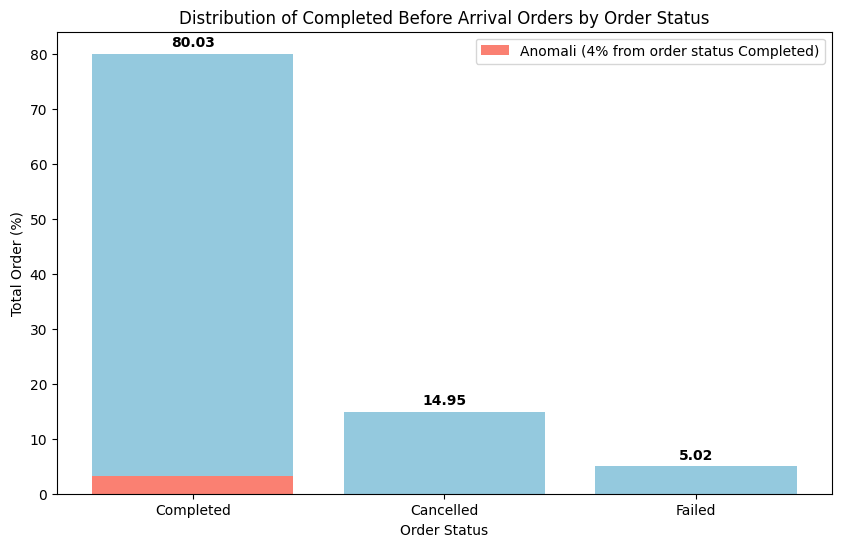

In [ ]:
# (4.5.1.2) Visualization 
##  Step 1: Prepare Data
status_counts = (df_food_orders_cleaned['order_status'].value_counts(normalize=True) * 100).round(decimals=2)
status_df = status_counts.reset_index()
status_df.columns = ['order_status', 'percentage']

## Step 2: Plot Bar Chart
plt.figure(figsize=(10, 6))
barplot = sns.barplot(data=status_df, x='order_status', y='percentage', color='skyblue')
for container in barplot.containers:
    barplot.bar_label(container, padding=3, fontsize=10, fontweight='bold')

## Step 3: Add anomaly bar
plt.bar(x=0, height=4 * (status_counts["Completed"]/100), color='salmon', label='Anomali (4% from order status Completed)')

plt.title('Distribution of Completed Before Arrival Orders by Order Status')
plt.xlabel('Order Status')
plt.ylabel('Total Order (%)')
plt.legend()
plt.show()

In [ ]:
# (4.5.2.1) Analyze Completed Before Driver Arrival Orders with promo_discount
# Step: Filter orders with completed_time is earlier than driver_arrived_time
# - Groups data by promo_discount to find total orders for each promo_discount
# - Calculate the filtered orders rate within each promo_discount

# 1. Get all food_orders with completed_time is earlier than driver_arrived_time
df_completed_early = df_food_orders_cleaned[df_food_orders_cleaned["driver_arrived_time"] >= df_food_orders_cleaned["completed_time"]]

# 2. Group by order_status
df_completed_early.groupby(["promo_discount"])["order_id"].count()

# 3. Calculate the rate compared to all promo_discount
pct_total_orders = ((df_food_orders_cleaned["promo_discount"].value_counts(normalize=True) * 100).round(2).rename("pct_total_orders"))
pct_by_promo = (df_completed_early["promo_discount"].value_counts() / df_food_orders_cleaned["promo_discount"].value_counts() * 100).round(2).rename("pct_by_status")
summary = pd.concat([pct_total_orders, pct_by_promo], axis=1).fillna(0)
print(summary)

                pct_total_orders  pct_by_status
promo_discount                                 
0                          39.40           0.00
10000                      19.13           0.00
20000                      14.34           0.00
15000                      14.30           0.00
30000                      12.83          24.95


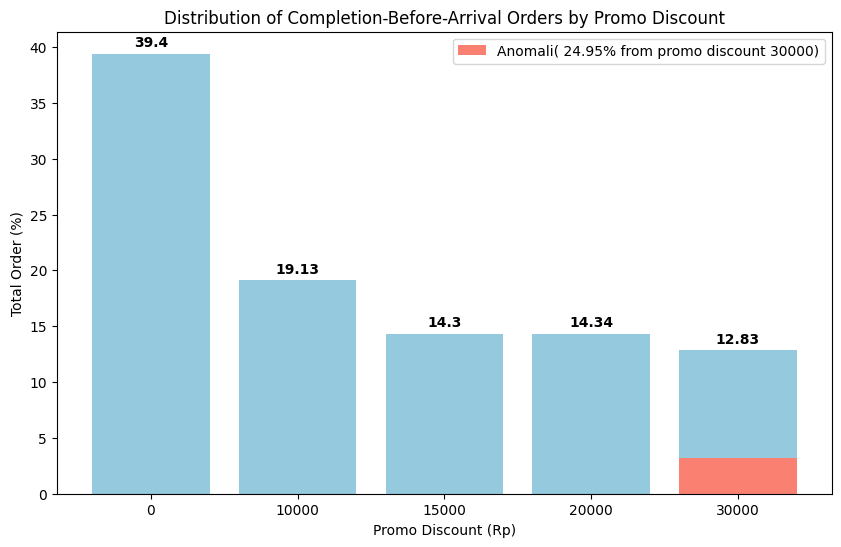

In [ ]:
# (4.5.2.2) Visualization 
##  Step 1: Prepare Data
promo_count = (df_food_orders_cleaned['promo_discount'].value_counts(normalize=True) * 100).round(decimals=2)
promo_df = promo_count.reset_index()
promo_df.columns = ['promo_discount', 'percentage']

## Step 2: Plot Bar Chart
plt.figure(figsize=(10, 6))
barplot = sns.barplot(data=promo_df, x='promo_discount', y='percentage', color='skyblue')
for container in barplot.containers:
    barplot.bar_label(container, padding=3, fontsize=10, fontweight='bold')

## Step 3: Add anomaly bar
plt.bar(x=4, height= 24.95 * (promo_count[30000]/100), color='salmon', label='Anomali( 24.95% from promo discount 30000)')

plt.title('Distribution of Completion-Before-Arrival Orders by Promo Discount')
plt.xlabel('Promo Discount (Rp)')
plt.ylabel('Total Order (%)')
plt.legend()
plt.show()

### **4.6 Question 6 Masalah Utama**

Kategori makanan (Cuisine Type) apa yang paling sering digunakan sebagai kedok oleh Resto Fiktif untuk memanipulasi harga menu tinggi?

---

#### **Key Insights & Metrics**

* **There is no any specific food category that might be used for fictitious merchant.** Given by the data by promo discount, all food categories have almost same proportion. Most of the orders don't use promo (39.2% - 39.7). By using assumption the fake orders will use the maximum promo discount (Rp 30000), all food categories only have range 12.6% - 13.1% and the food category with the highest rate (13.1%) is seafood.
* **Cancellation reason: "Restaurant Not Found" may indicates fictitious merchant.** The distribution of these cancellations are relatively consistent across food categories, ranging from 15.70% to 17.06%,  also indicating no category stands out. The food category with the highest rate (17.06%) is Martabak.
* **The findings do not support the assumption that suspected fictitious orders can be mainly driven by GrabUnlimited users.** The data show across every food category, approximately 60% of "Restaurant Not Found" cancellations is from non-GrabUnlimited users, while 40% come from GrabUnlimited users.

In [ ]:
# (4.6.1.1) Analyze orders' cuisine_type  with promo_discount
# Step: 
# - Merge food_orders with merchants
# - Groups data by promo_discount
# - Calculate rate of each cuisine_type for each promo_discount

# 1. Merge food_orders with merchants table to identify total orders for each cuisine_type
df_orders_merchant = df_food_orders_cleaned.merge(df_merchants_cleaned[["merchant_id", "cuisine_type"]], on="merchant_id")

# 2. Group by promo_discount and calculate rate
(df_orders_merchant.groupby(["promo_discount"])['cuisine_type'].value_counts(normalize=True) * 100).round(decimals=2)

promo_discount  cuisine_type
0               Ayam Geprek     17.24
                Seafood         17.02
                Martabak        16.71
                Fast Food       16.71
                Snacks          16.58
                Beverages       15.75
10000           Ayam Geprek     17.27
                Fast Food       17.11
                Seafood         16.95
                Martabak        16.77
                Snacks          16.15
                Beverages       15.75
15000           Ayam Geprek     17.31
                Seafood         17.20
                Fast Food       16.72
                Martabak        16.43
                Snacks          16.25
                Beverages       16.09
20000           Ayam Geprek     17.32
                Seafood         16.88
                Fast Food       16.83
                Snacks          16.53
                Martabak        16.50
                Beverages       15.94
30000           Seafood         17.39
                Ayam 

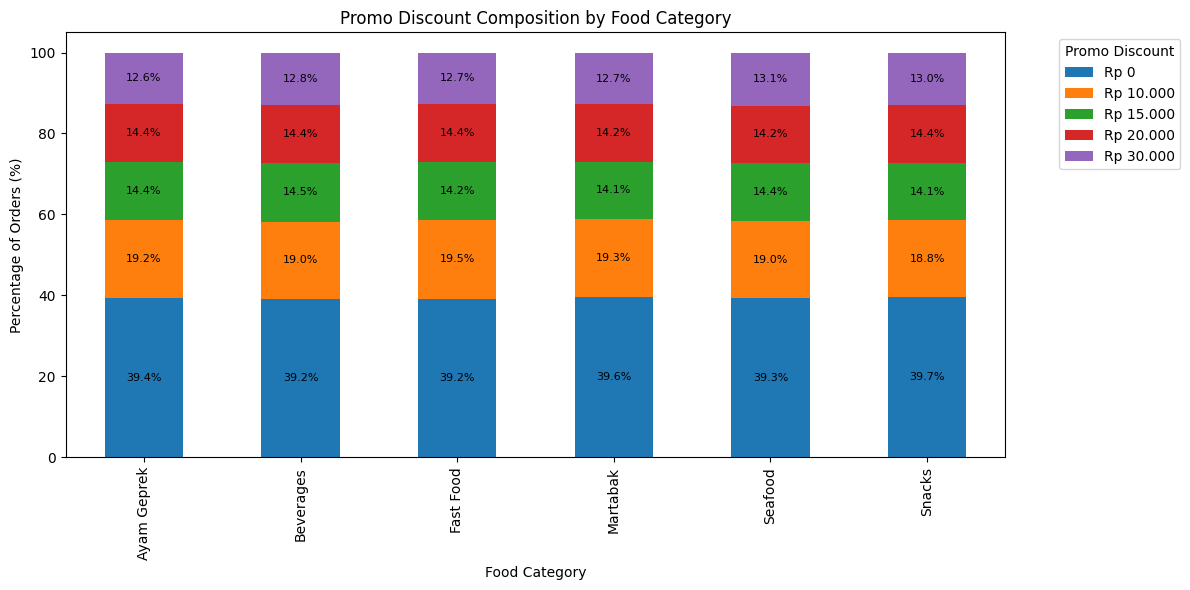

In [ ]:
# (4.6.1.2) Visualization 
# Crosstab: Food Category vs Promo Discount
promo_dist = pd.crosstab(
    df_orders_merchant["cuisine_type"],
    df_orders_merchant["promo_discount"],
    normalize="index"
) * 100

promo_dist.columns = [
    f"Rp {int(col):,}".replace(",", ".")
    for col in promo_dist.columns
]

promo_dist = promo_dist.round(1)

# Plot
ax = promo_dist.plot(
    kind="bar",
    stacked=True,
    figsize=(12, 6)
)

# Tambahkan label persentase
for container in ax.containers:
    labels = [
        f'{bar.get_height():.1f}%'
        if bar.get_height() > 5 else ''  # hanya tampilkan jika > 5%
        for bar in container
    ]
    ax.bar_label(
        container,
        labels=labels,
        label_type='center',
        fontsize=8
    )

plt.title("Promo Discount Composition by Food Category")
plt.xlabel("Food Category")
plt.ylabel("Percentage of Orders (%)")
plt.legend(title="Promo Discount", bbox_to_anchor=(1.05, 1))
plt.tight_layout()

plt.show()

In [ ]:
# (4.6.2.1) Analyze Cuisine Type Orders with Cancellation Reason "Restaurant Not Found"
# Indicate fake restaurants by orders with cancellation reason is "Restaurant Not Found"
# Step:
# - Filter orders with cancellation reason is Restaurant Not Found
# - Groups data by cuisine_type
# - Calculate the cancellation rate for the reason "Restaurant Not Foudn" of each cuisine_type 

# 1. Filter orders with cancellation reason is Restaurant Not Found
df_resto_not_found = df_orders_merchant[df_orders_merchant["cancel_reason"] == "Resto Tidak Ditemukan"]

#2. Group data by cuisine_type & calculate the rate
(df_resto_not_found["cuisine_type"].value_counts(normalize=True) * 100).round(decimals=2)


cuisine_type
Martabak       17.06
Seafood        16.90
Fast Food      16.86
Ayam Geprek    16.82
Snacks         16.67
Beverages      15.70
Name: proportion, dtype: float64

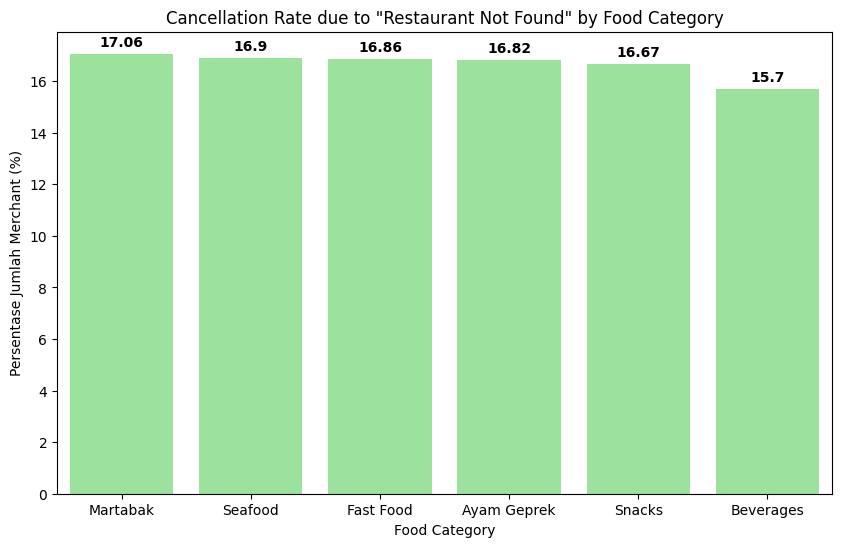

In [107]:
# (4.6.2.2) Visualization
# 1. Prepare Data
resto_not_found_count = (df_resto_not_found["cuisine_type"].value_counts(normalize=True) * 100).round(decimals=2)
resto_not_found_df = resto_not_found_count.reset_index()
resto_not_found_df.columns = ['cuisine_type', 'percentage']

# 2. Plot Bar Chart
plt.figure(figsize=(10, 6))
barplot = sns.barplot(data=resto_not_found_df, x='cuisine_type', y='percentage', color='lightgreen')
for container in barplot.containers:
    barplot.bar_label(container, padding=3, fontsize=10, fontweight='bold')

plt.title('Cancellation Rate due to "Restaurant Not Found" by Food Category')
plt.xlabel("Food Category")
plt.ylabel('Persentase Jumlah Merchant (%)')
plt.show()

In [128]:
# (4.6.3.1) Analyze Cuisine Type Orders with Grab Unlimited Users
# Indicate fake orders with cancellation reason is "Restaurant Not Found" by Grab Unlimited Users
# Step:
# - Merge orders, merchants with users table
# - Filter orders with cancellation reason is Restaurant Not Found
# - Groups data by cuisine_type
# - Calculate the cancellation rate for the reason "Restaurant Not Foudn" of each cuisine_type 

# 1. Merge orders_merchants with users table to identify orders by Grab Unlimited Users
df_orders_merchant_users = df_orders_merchant.merge(df_users_cleaned[["user_id", "is_grab_unlimited"]], on="user_id")

# 2. Filter orders with cancel_reason == "Resto Tidak Ditemukan" and is_grab_unlimited == True
df_resto_not_found = df_orders_merchant_users[
    (df_orders_merchant_users["cancel_reason"] == "Resto Tidak Ditemukan")
    & (df_orders_merchant_users["is_grab_unlimited"] == True)]

# 3. Group data by cuisine_type & calculate the rate
(df_resto_not_found["cuisine_type"].value_counts(normalize=True) * 100).round(decimals=2)

# 3. Calculate the rate compared to all promo_discount
df_resto_not_found = df_orders_merchant_users[df_orders_merchant_users["cancel_reason"] == "Resto Tidak Ditemukan"]
summary = (pd.crosstab(df_resto_not_found["cuisine_type"],df_resto_not_found["is_grab_unlimited"], normalize='index') * (100)).round(2)
print(summary)

is_grab_unlimited  False  True 
cuisine_type                   
Ayam Geprek        61.63  38.37
Beverages          60.52  39.48
Fast Food          60.27  39.73
Martabak           60.72  39.28
Seafood            61.60  38.40
Snacks             61.28  38.72


In [114]:
df_resto_not_found.head()

,order_id,merchant_id,user_id,order_status,promo_discount,cancel_reason,order_time,driver_arrived_time,completed_time,promo_discount_sentinel,...,driver_arrived_year,driver_arrived_month,driver_arrived_day,driver_arrived_day_name,completed_year,completed_month,completed_day,completed_day_name,cuisine_type,is_grab_unlimited
1,GF-ORD-00000002,GF-07698,GB-019520,Cancelled,0,Resto Tidak Ditemukan,2023-12-20 14:01:00,2023-12-20 14:13:00,NaT,False,...,2023,12,20,Wednesday,<NA>,<NA>,<NA>,NaN,Ayam Geprek,True
102,GF-ORD-00000103,GF-07223,GB-036476,Failed,30000,Resto Tidak Ditemukan,2023-12-30 14:07:00,2023-12-30 14:24:00,NaT,False,...,2023,12,30,Saturday,<NA>,<NA>,<NA>,NaN,Fast Food,True
240,GF-ORD-00000241,GF-03457,GB-035803,Failed,15000,Resto Tidak Ditemukan,2024-03-07 08:29:00,NaT,NaT,False,...,<NA>,<NA>,<NA>,NaN,<NA>,<NA>,<NA>,NaN,Ayam Geprek,True
261,GF-ORD-00000262,GF-04070,GB-011745,Failed,0,Resto Tidak Ditemukan,2024-03-24 13:06:00,NaT,NaT,False,...,<NA>,<NA>,<NA>,NaN,<NA>,<NA>,<NA>,NaN,Fast Food,True
425,GF-ORD-00000426,GF-06355,GB-004239,Failed,10000,Resto Tidak Ditemukan,2023-12-16 22:31:00,2023-12-16 22:38:00,NaT,False,...,2023,12,16,Saturday,<NA>,<NA>,<NA>,NaN,Martabak,True


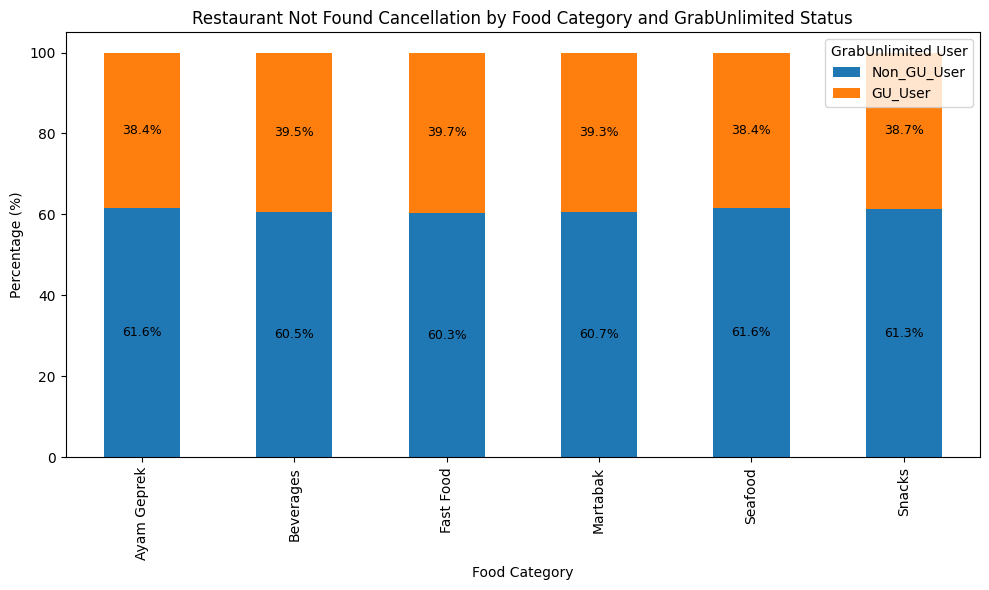

In [129]:
# (4.6.3.2) Visualization
# 1. Prepare Data
summary = (
    pd.crosstab(
        df_resto_not_found["cuisine_type"],
        df_resto_not_found["is_grab_unlimited"],
        normalize='index'
    ) * 100
).round(2)

summary = summary.reset_index()

# Rename columns biar lebih jelas
summary.columns = ['cuisine_type', 'Non_GU_User', 'GU_User']

# 2. Plot Stacked Bar Chart
ax = summary.set_index('cuisine_type').plot(
    kind='bar',
    stacked=True,
    figsize=(10, 6)
)

# Add labels
for container in ax.containers:
    ax.bar_label(
        container,
        fmt='%.1f%%',
        label_type='center',
        fontsize=9
    )

plt.title('Restaurant Not Found Cancellation by Food Category and GrabUnlimited Status')
plt.xlabel('Food Category')
plt.ylabel('Percentage (%)')
plt.legend(title='GrabUnlimited User')
plt.tight_layout()
plt.show()

## **Section 5. Conclusion and Recommendation**

**5.1 Conclusion**

**5.2 Recommendation**